# LLM-selected SMAC random-forest policy

This notebook compares the original raw-history OpenAI/LLM RF policy, the compact-summary OpenAI/LLM RF policy, and fixed RF-depth controls on the two O1 deterministic benchmark landscapes used by this experiment (benchmark seeds 40 and 42).

The optimization objective is minimized. Every trajectory uses the stored `best_so_far` value: the best full 10-instance objective value discovered by that trial. This is not the raw cost from one instance evaluation.

For a fair comparison, all analyses use the five SMAC seeds shared by both LLM experiments and controls: seeds 0–4. The fixed controls come from `09_big_experiment` and differ only in their fixed maximum RF depth (5, 10, 15, or 20).

In [1]:
from pathlib import Path
import json
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_colwidth', 120)


def locate_experiment_dir():
    relative = Path('experiments/synthaticBench/o1_deterministic/depth_policies/40_llm_chooses')
    candidates = [Path.cwd(), *Path.cwd().parents]
    for candidate in candidates:
        direct = candidate if candidate.name == '40_llm_chooses' else candidate / relative
        if (direct / 'smac_output').is_dir():
            return direct.resolve()
    raise FileNotFoundError('Could not locate 40_llm_chooses/smac_output from the current directory.')


HERE = locate_experiment_dir()
FIXED_ROOT = HERE.parent / '09_big_experiment' / 'smac_output' / 'fixed'
BENCHMARK_SEEDS = (40, 42)
SMAC_SEEDS = tuple(range(5))
DEPTHS = (5, 10, 15, 20)
N_TRIALS = 1000

print(f'LLM results:   {HERE / "smac_output"}')
print(f'Fixed results: {FIXED_ROOT}')

LLM results:   /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/40_llm_chooses/smac_output
Fixed results: /rwthfs/rz/cluster/home/io632776/experiments/adaptive-smac/experiments/synthaticBench/o1_deterministic/depth_policies/09_big_experiment/smac_output/fixed


## Load and validate trajectories

The table confirms which files are included and checks that every run contains all 1,000 requested trials. A run is only admitted if its benchmark seed, SMAC seed, and stored trajectory agree with the path.

In [2]:
def load_trajectory(path, benchmark_seed, smac_seed, policy):
    if not path.exists():
        raise FileNotFoundError(path)
    payload = json.loads(path.read_text())
    if int(payload['benchmark_seed']) != benchmark_seed:
        raise ValueError(f'Benchmark-seed mismatch in {path}')
    if int(payload['smac_seed']) != smac_seed:
        raise ValueError(f'SMAC-seed mismatch in {path}')
    iterations = np.asarray(payload['iteration'], dtype=int)
    best = np.asarray(payload['best_so_far'], dtype=float)
    if len(iterations) != len(best):
        raise ValueError(f'Unequal iteration and best_so_far lengths in {path}')
    return {
        'benchmark_seed': benchmark_seed,
        'smac_seed': smac_seed,
        'policy': policy,
        'iteration': iterations,
        'best_so_far': best,
        'payload': payload,
        'path': path,
    }


runs = []
for benchmark_seed in BENCHMARK_SEEDS:
    for smac_seed in SMAC_SEEDS:
        llm_path = (HERE / 'smac_output' / f'benchmark_seed_{benchmark_seed}' /
                    'openai_llm_rf_policy' / str(smac_seed) / 'trajectory.json')
        runs.append(load_trajectory(llm_path, benchmark_seed, smac_seed, 'Original LLM'))
        compact_path = (HERE / 'smac_output' / f'benchmark_seed_{benchmark_seed}' /
                        'openai_compact_llm_rf_policy' / str(smac_seed) / 'trajectory.json')
        runs.append(load_trajectory(compact_path, benchmark_seed, smac_seed, 'Compact LLM'))
        for depth in DEPTHS:
            fixed_path = (FIXED_ROOT / f'benchmark_seed_{benchmark_seed}' /
                          f'fixed_depth_{depth}' / str(smac_seed) / 'trajectory.json')
            runs.append(load_trajectory(fixed_path, benchmark_seed, smac_seed, f'Fixed depth {depth}'))

coverage = pd.DataFrame([
    {
        'benchmark_seed': r['benchmark_seed'],
        'policy': r['policy'],
        'smac_seed': r['smac_seed'],
        'trials': len(r['iteration']),
        'final_best_cost': r['best_so_far'][-1],
    }
    for r in runs
])

assert len(runs) == len(BENCHMARK_SEEDS) * len(SMAC_SEEDS) * (2 + len(DEPTHS))
assert coverage['trials'].eq(N_TRIALS).all(), 'At least one trajectory is incomplete.'
display(coverage.groupby(['benchmark_seed', 'policy'], sort=False).agg(
    runs=('smac_seed', 'nunique'),
    minimum_trials=('trials', 'min'),
    maximum_trials=('trials', 'max'),
).reset_index())

,benchmark_seed,policy,runs,minimum_trials,maximum_trials
0,40,Original LLM,5,1000,1000
1,40,Compact LLM,5,1000,1000
2,40,Fixed depth 5,5,1000,1000
3,40,Fixed depth 10,5,1000,1000
4,40,Fixed depth 15,5,1000,1000
5,40,Fixed depth 20,5,1000,1000
6,42,Original LLM,5,1000,1000
7,42,Compact LLM,5,1000,1000
8,42,Fixed depth 5,5,1000,1000
9,42,Fixed depth 10,5,1000,1000


## 1. Original LLM-policy trajectories by benchmark seed

Each plot fixes one benchmark landscape and shows one original raw-history LLM-policy line per SMAC seed. A downward step means that SMAC discovered a configuration with a better full 10-instance objective value. Differences between lines show sensitivity to SMAC's random seed.

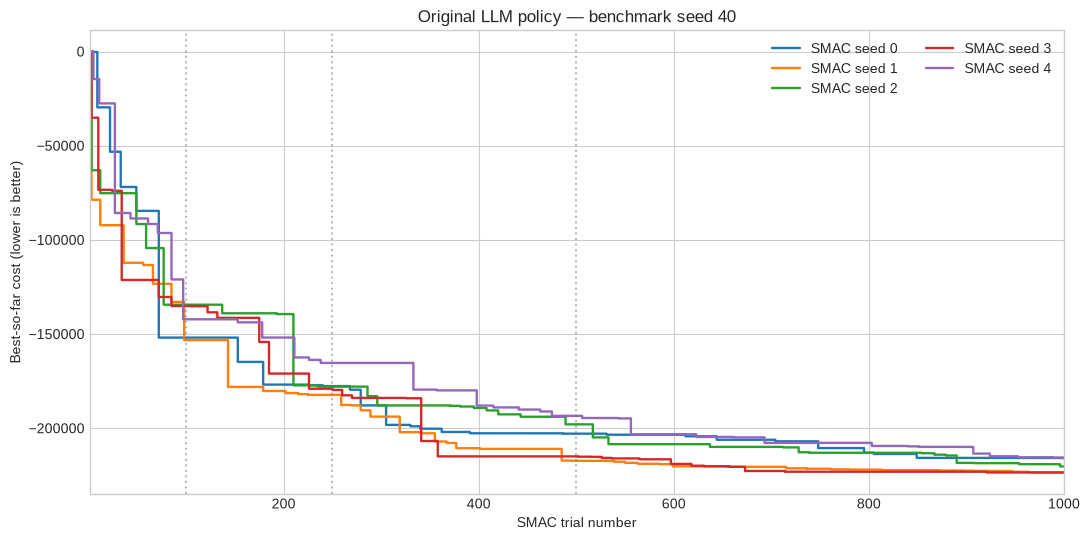

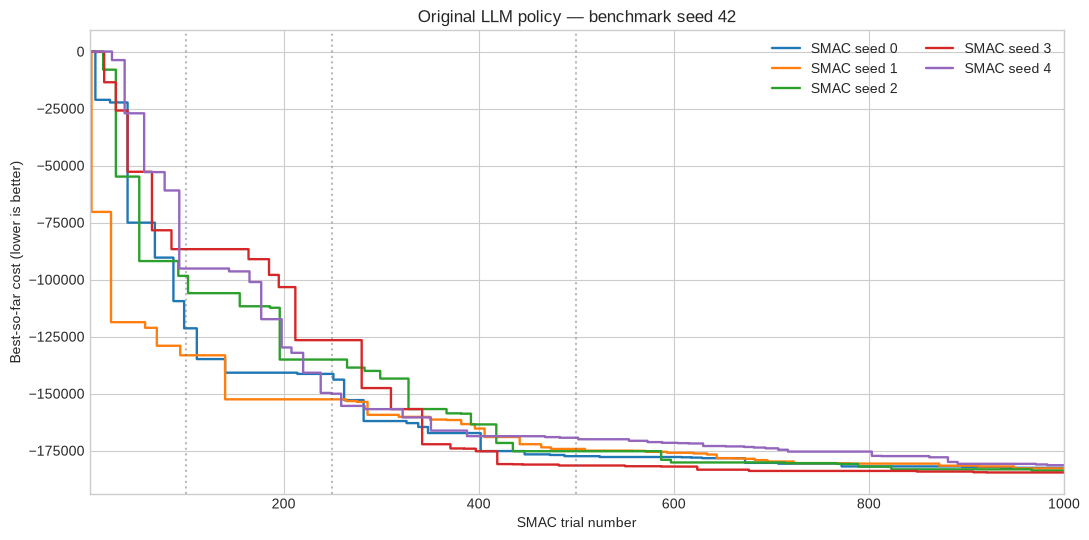

In [3]:
for benchmark_seed in BENCHMARK_SEEDS:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    selected = [r for r in runs if r['benchmark_seed'] == benchmark_seed and r['policy'] == 'Original LLM']
    for run in selected:
        ax.step(run['iteration'], run['best_so_far'], where='post',
                label=f"SMAC seed {run['smac_seed']}", linewidth=1.7)
    for checkpoint in (100, 250, 500):
        ax.axvline(checkpoint, color='0.4', linestyle=':', alpha=0.45)
    ax.set(title=f'Original LLM policy — benchmark seed {benchmark_seed}',
           xlabel='SMAC trial number', ylabel='Best-so-far cost (lower is better)',
           xlim=(1, N_TRIALS))
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 1b. Compact LLM-policy trajectories by benchmark seed

These are the exact counterparts of the preceding plots for the compact-summary LLM policy. Each figure shows all five SMAC seeds for one benchmark landscape, with the LLM checkpoints marked at trials 100, 250, and 500.

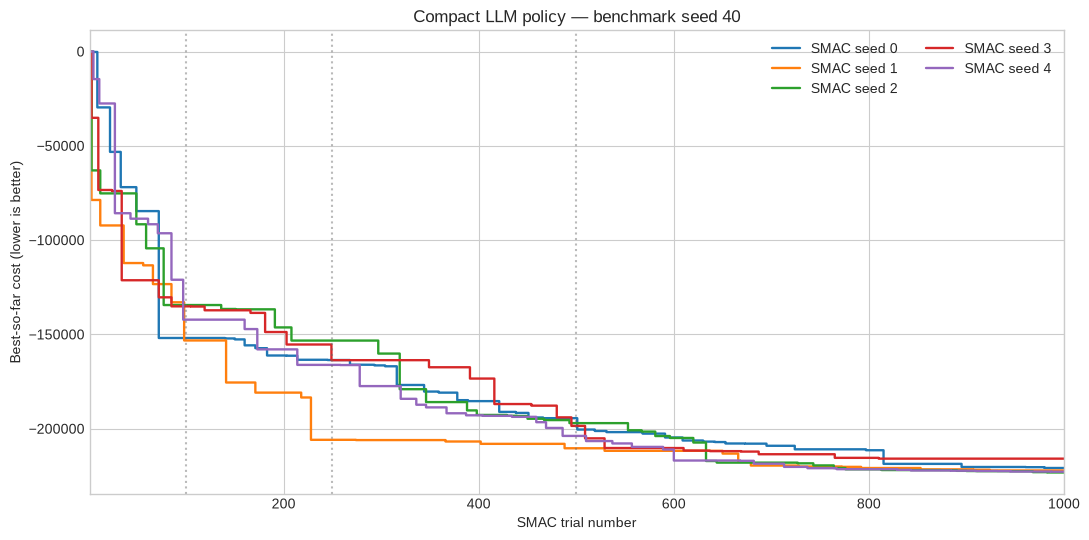

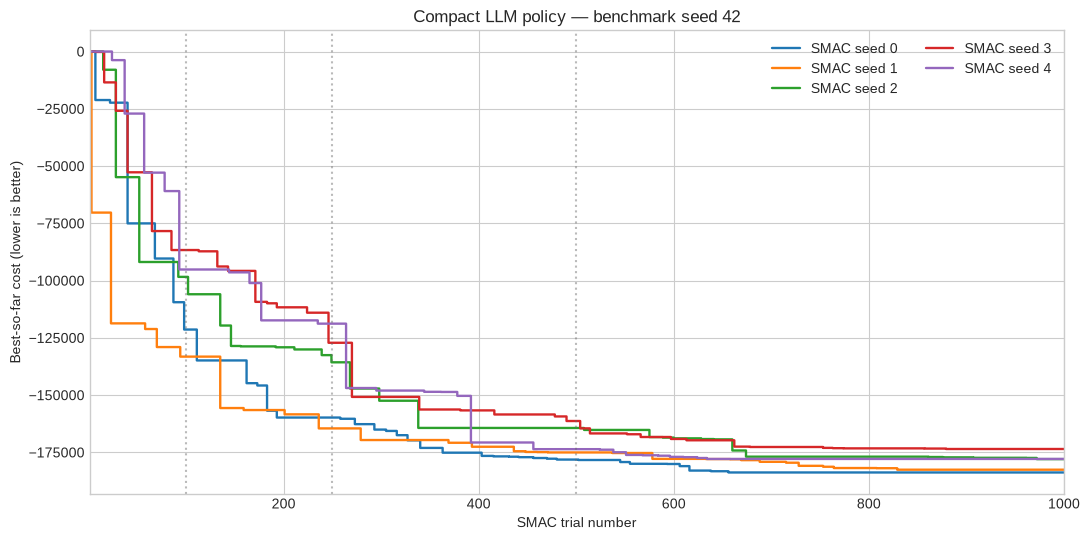

In [4]:
for benchmark_seed in BENCHMARK_SEEDS:
    fig, ax = plt.subplots(figsize=(11, 5.5))
    selected = [r for r in runs if r['benchmark_seed'] == benchmark_seed and r['policy'] == 'Compact LLM']
    for run in selected:
        ax.step(run['iteration'], run['best_so_far'], where='post',
                label=f"SMAC seed {run['smac_seed']}", linewidth=1.7)
    for checkpoint in (100, 250, 500):
        ax.axvline(checkpoint, color='0.4', linestyle=':', alpha=0.45)
    ax.set(title=f'Compact LLM policy — benchmark seed {benchmark_seed}',
           xlabel='SMAC trial number', ylabel='Best-so-far cost (lower is better)',
           xlim=(1, N_TRIALS))
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 2. Original and compact LLM policies versus fixed depths, with confidence intervals

For each benchmark landscape, the solid line is the arithmetic mean best-so-far cost at every trial across the same five SMAC seeds (0–4). The shaded region is a two-sided 95% Student-t confidence interval for that mean. With only five seeds, these intervals can be wide; they describe uncertainty in the mean across SMAC seeds, not the spread of individual runs.

The vertical dotted lines mark both LLM policies' decision checkpoints. Fixed policies do not change at those lines.

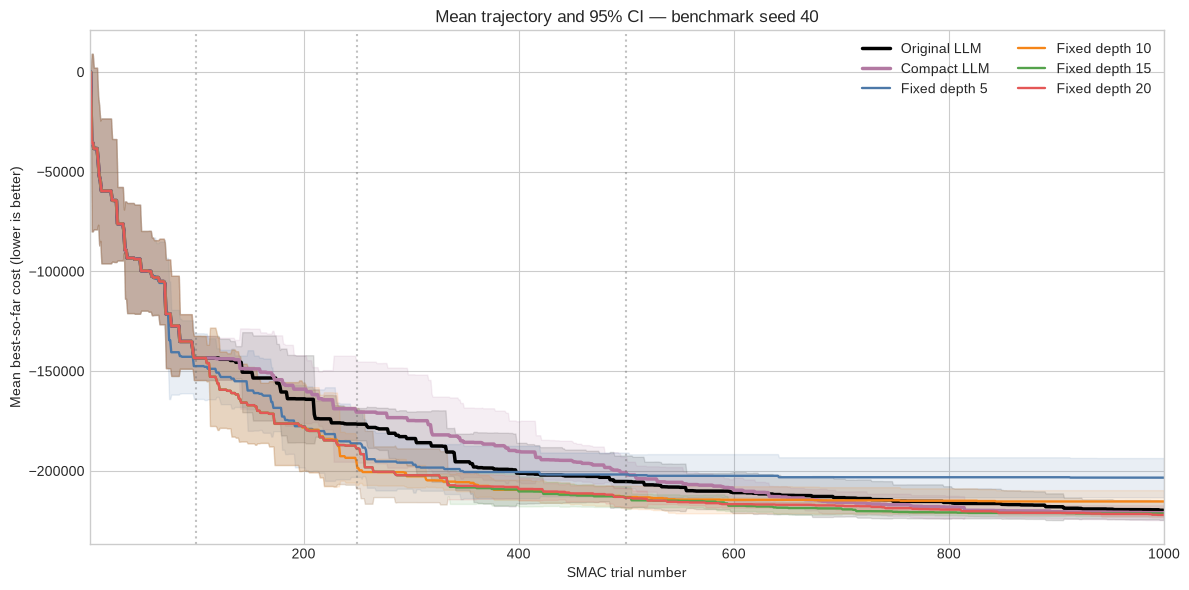

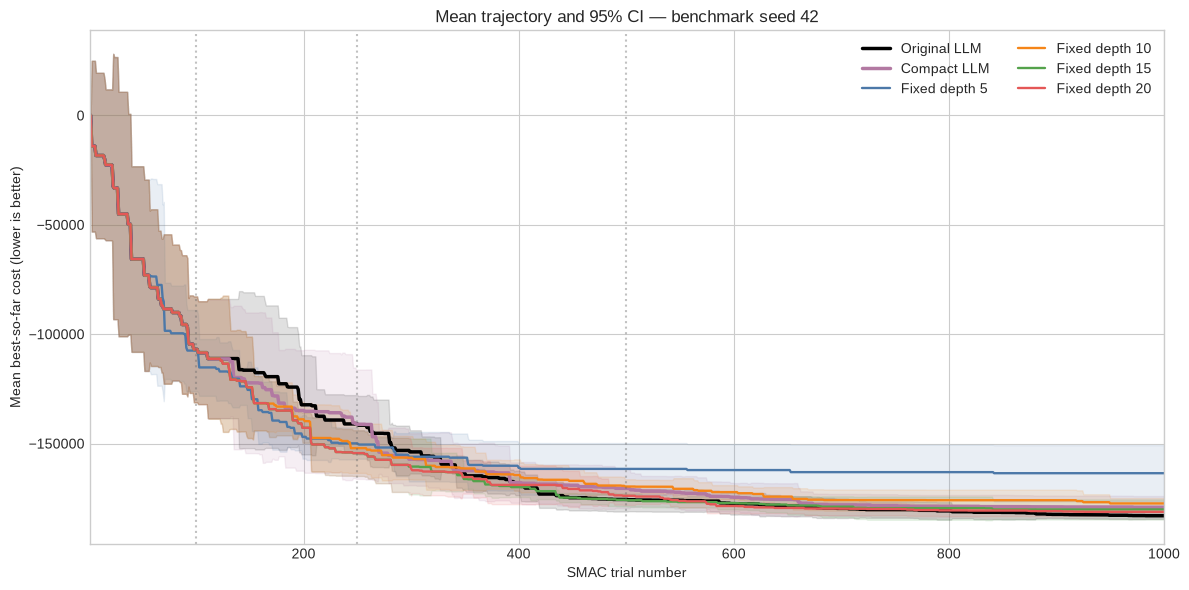

In [5]:
# Two-sided Student-t 97.5% critical values indexed by sample size.
T_CRIT_95 = {2: 12.706, 3: 4.303, 4: 3.182, 5: 2.776,
             6: 2.571, 7: 2.447, 8: 2.365, 9: 2.306, 10: 2.262}


def mean_and_ci(curves):
    matrix = np.vstack(curves)
    n = matrix.shape[0]
    mean = matrix.mean(axis=0)
    if n < 2:
        return mean, np.full_like(mean, np.nan), np.full_like(mean, np.nan)
    half_width = T_CRIT_95.get(n, 1.96) * matrix.std(axis=0, ddof=1) / math.sqrt(n)
    return mean, mean - half_width, mean + half_width


POLICY_ORDER = ['Original LLM', 'Compact LLM'] + [f'Fixed depth {depth}' for depth in DEPTHS]
COLORS = dict(zip(POLICY_ORDER, ['black', '#B279A2', '#4C78A8', '#F58518', '#54A24B', '#E45756']))

for benchmark_seed in BENCHMARK_SEEDS:
    fig, ax = plt.subplots(figsize=(12, 6))
    for policy in POLICY_ORDER:
        selected = sorted(
            (r for r in runs if r['benchmark_seed'] == benchmark_seed and r['policy'] == policy),
            key=lambda r: r['smac_seed'],
        )
        mean, lower, upper = mean_and_ci([r['best_so_far'] for r in selected])
        x = selected[0]['iteration']
        width = 2.5 if policy in ('Original LLM', 'Compact LLM') else 1.7
        ax.plot(x, mean, label=policy, color=COLORS[policy], linewidth=width)
        ax.fill_between(x, lower, upper, color=COLORS[policy], alpha=0.12)
    for checkpoint in (100, 250, 500):
        ax.axvline(checkpoint, color='0.4', linestyle=':', alpha=0.4)
    ax.set(title=f'Mean trajectory and 95% CI — benchmark seed {benchmark_seed}',
           xlabel='SMAC trial number', ylabel='Mean best-so-far cost (lower is better)',
           xlim=(1, N_TRIALS))
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 3. Final-incumbent comparison

Each boxplot summarizes the five final best-so-far costs at trial 1,000. Every point is one SMAC seed and is shown explicitly because five samples are too few for a box alone to communicate the data. Lower values are better. The accompanying table reports the mean, standard deviation, median, minimum, and maximum.

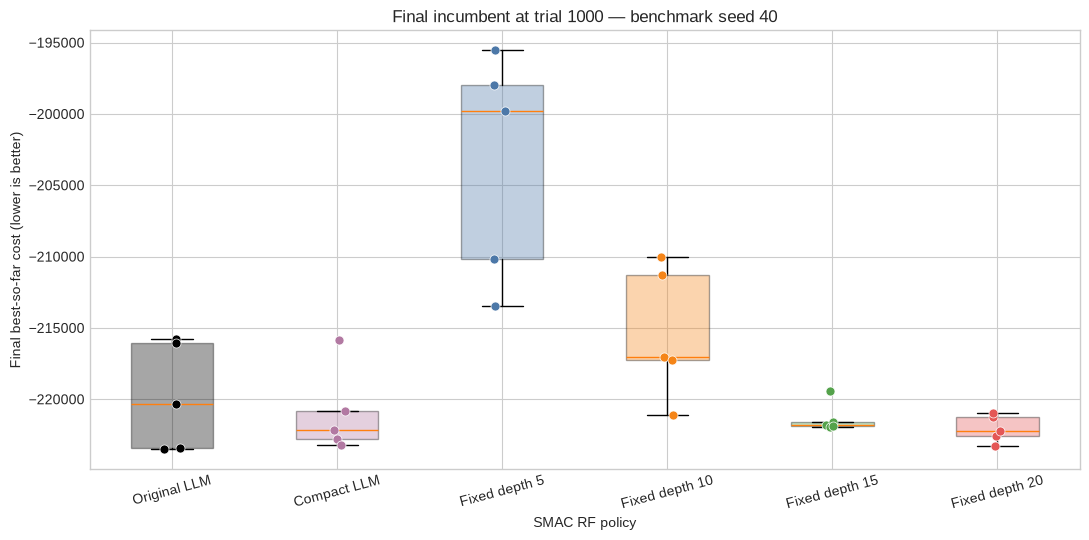

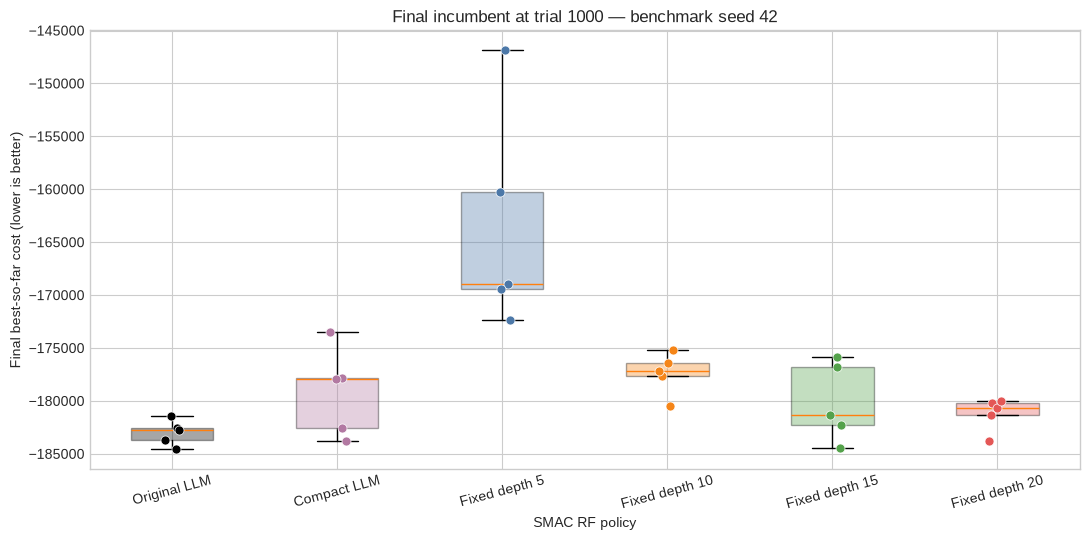

,benchmark_seed,policy,count,mean,std,median,min,max
0,40,Original LLM,5,"-219,823.219","3,771.138","-220,312.126","-223,508.105","-215,811.264"
1,40,Compact LLM,5,"-220,968.481","2,985.225","-222,135.886","-223,205.783","-215,876.942"
2,40,Fixed depth 5,5,"-203,387.614","7,930.280","-199,814.746","-213,474.631","-195,546.614"
3,40,Fixed depth 10,5,"-215,331.290","4,566.102","-217,010.021","-221,072.959","-210,062.828"
4,40,Fixed depth 15,5,"-221,340.943","1,078.240","-221,791.776","-221,973.425","-219,425.624"
5,40,Fixed depth 20,5,"-222,054.689",944.574,"-222,219.208","-223,247.449","-220,989.200"
6,42,Original LLM,5,"-183,001.981","1,206.410","-182,795.298","-184,569.619","-181,392.392"
7,42,Compact LLM,5,"-179,116.993","4,116.312","-177,923.527","-183,755.411","-173,508.302"
8,42,Fixed depth 5,5,"-163,557.960","10,354.485","-168,914.802","-172,343.800","-146,879.126"
9,42,Fixed depth 10,5,"-177,380.689","1,988.021","-177,159.341","-180,503.613","-175,146.973"


In [6]:
finals = coverage.copy()
finals['policy'] = pd.Categorical(finals['policy'], POLICY_ORDER, ordered=True)

for benchmark_seed in BENCHMARK_SEEDS:
    part = finals[finals['benchmark_seed'] == benchmark_seed].sort_values('policy')
    values = [part.loc[part['policy'] == policy, 'final_best_cost'].to_numpy() for policy in POLICY_ORDER]
    fig, ax = plt.subplots(figsize=(11, 5.5))
    boxes = ax.boxplot(values, tick_labels=POLICY_ORDER, patch_artist=True, showfliers=False)
    for box, policy in zip(boxes['boxes'], POLICY_ORDER):
        box.set_facecolor(COLORS[policy])
        box.set_alpha(0.35)
    rng = np.random.default_rng(benchmark_seed)
    for position, (policy, vals) in enumerate(zip(POLICY_ORDER, values), start=1):
        jitter = rng.uniform(-0.055, 0.055, len(vals))
        ax.scatter(position + jitter, vals, color=COLORS[policy], edgecolor='white',
                   linewidth=0.5, s=42, zorder=3)
    ax.set(title=f'Final incumbent at trial {N_TRIALS} — benchmark seed {benchmark_seed}',
           xlabel='SMAC RF policy', ylabel='Final best-so-far cost (lower is better)')
    ax.tick_params(axis='x', rotation=15)
    plt.tight_layout()
    plt.show()

summary = (finals.groupby(['benchmark_seed', 'policy'], observed=True)['final_best_cost']
           .agg(['count', 'mean', 'std', 'median', 'min', 'max']).reset_index())
display(summary.style.format({column: '{:,.3f}' for column in ['mean', 'std', 'median', 'min', 'max']}))

## 4. Hyperparameters selected at each stage

Rows below show the RF settings actually active during each trial interval for both LLM policies. Trials 1–100 use SMAC's configured default RF settings. The response obtained at checkpoint 100 applies to trials 101–250, the checkpoint-250 response applies to trials 251–500, and the checkpoint-500 response applies to trials 501–1,000.

`feature_ratio` is the fraction of configuration dimensions considered at a split. `confidence` is the LLM's self-reported confidence, not a statistically calibrated probability.

In [7]:
STAGES = [
    ('Trials 1–100 (default)', None),
    ('Trials 101–250', '100'),
    ('Trials 251–500', '250'),
    ('Trials 501–1000', '500'),
]

selection_rows = []
for run in (r for r in runs if r['policy'] in ('Original LLM', 'Compact LLM')):
    payload = run['payload']
    decisions = payload['llm_policy']['decisions']
    for stage, checkpoint in STAGES:
        if checkpoint is None:
            settings = payload['default_rf_settings']
            confidence = np.nan
            reason = 'SMAC RF defaults used before the first LLM call.'
        else:
            decision = decisions[checkpoint]
            settings = decision['settings']
            confidence = decision.get('confidence', np.nan)
            reason = decision.get('reason', '')
        selection_rows.append({
            'benchmark_seed': run['benchmark_seed'],
            'smac_seed': run['smac_seed'],
            'policy': run['policy'],
            'stage': stage,
            'n_trees': settings['n_trees'],
            'max_depth': settings['max_depth'],
            'min_samples_split': settings['min_samples_split'],
            'min_samples_leaf': settings['min_samples_leaf'],
            'feature_ratio': settings['feature_ratio'],
            'confidence': confidence,
            'reason': reason,
        })

selections = pd.DataFrame(selection_rows)
stage_order = [stage for stage, _ in STAGES]
selections['stage'] = pd.Categorical(selections['stage'], stage_order, ordered=True)
display(selections.sort_values(['benchmark_seed', 'policy', 'smac_seed', 'stage']).style.format({
    'feature_ratio': '{:.3f}', 'confidence': lambda value: '' if pd.isna(value) else f'{value:.2f}'
}))

,benchmark_seed,smac_seed,policy,stage,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,confidence,reason
4,40,0,Compact LLM,Trials 1–100 (default),10,20,3,3,0.833,,SMAC RF defaults used before the first LLM call.
5,40,0,Compact LLM,Trials 101–250,100,12,2,1,0.800,0.72,"Increase ensemble stability and allow finer local modeling; current trees only reach depth about 5 despite a depth limit of 20, while recent proxy errors remain substantial and uncertainty calibration is weak. A moderate depth cap and feature subsampling retain useful RF diversity."
6,40,0,Compact LLM,Trials 251–500,100,20,2,1,0.800,0.74,"Recent trees are consistently depth-capped (mean utilization 0.96 at the depth-12 limit), while the incumbent has nearly plateaued. Increasing the depth limit should recover useful local discrimination without changing the recently improved leaf-level resolution, feature subsampling, or ensemble stability."
7,40,0,Compact LLM,Trials 501–1000,100,25,2,1,0.900,0.72,"Recent trees use about 81% of the depth-20 limit and their realized depth is still increasing, so a modest depth increase should reduce persistent underprediction without imposing an unnecessarily large cap. Preserve fully grown leaves and 100 trees; slightly increase feature usage for this low-dimensional continuous space."
12,40,1,Compact LLM,Trials 1–100 (default),10,20,3,3,0.833,,SMAC RF defaults used before the first LLM call.
13,40,1,Compact LLM,Trials 101–250,80,12,2,1,1.000,0.78,"Recent surrogate errors remain material and predictions lag newly improved costs, while actual depths (~5) are far below the current limit of 20. More trees should stabilize EI and variance estimates; smaller leaves and splits allow needed local refinement in the 10D continuous space. A depth limit of 12 preserves capacity without an unnecessarily loose limit, and all features per split supports interactions across the modest-dimensional space."
14,40,1,Compact LLM,Trials 251–500,100,16,2,1,1.000,0.74,"Current trees are depth-saturated (recent utilization about 0.98 at limit 12), while the latest improvement is substantial but marginalized predictions lag observed costs. Raising the depth limit should capture remaining structure; retain minimally constrained leaves and full features for the 10-D continuous space, and increase trees modestly to stabilize acquisition variance."
15,40,1,Compact LLM,Trials 501–1000,100,20,2,1,1.000,0.76,"Recent trees consistently saturate the depth-16 limit while proposal errors remain nontrivial and variance-error correlation is positive. Increase depth moderately to reduce underfitting; retain the otherwise effective full-feature, fully grown, 100-tree forest."
20,40,2,Compact LLM,Trials 1–100 (default),10,20,3,3,0.833,,SMAC RF defaults used before the first LLM call.
21,40,2,Compact LLM,Trials 101–250,60,12,2,2,0.800,0.72,"Increase the very small 10-tree ensemble to stabilize marginalized means and variance estimates, whose error correlation has recently been inconsistent. The observed depth near 5.6 shows depth 20 is unused, so a 12-depth limit preserves realized complexity. Slightly smaller leaves and split threshold allow useful local refinement in the 10-D continuous space while retaining regularization with about 99 training rows."


### Selection frequencies

This compact table counts how often each complete RF setting was selected in a stage across the five SMAC seeds, separately for each LLM policy and benchmark landscape. It makes convergence on the same setting—and deviations from it—easy to see.

In [8]:
setting_columns = ['n_trees', 'max_depth', 'min_samples_split', 'min_samples_leaf', 'feature_ratio']
frequencies = (selections.groupby(['benchmark_seed', 'policy', 'stage', *setting_columns], observed=True)
               .size().rename('number_of_smac_seeds').reset_index()
               .sort_values(['benchmark_seed', 'policy', 'stage', 'number_of_smac_seeds'],
                            ascending=[True, True, True, False]))
display(frequencies.style.format({'feature_ratio': '{:.3f}'}))

,benchmark_seed,policy,stage,n_trees,max_depth,min_samples_split,min_samples_leaf,feature_ratio,number_of_smac_seeds
0,40,Compact LLM,Trials 1–100 (default),10,20,3,3,0.833,5
1,40,Compact LLM,Trials 101–250,60,12,2,2,0.800,1
2,40,Compact LLM,Trials 101–250,80,12,2,1,1.000,1
3,40,Compact LLM,Trials 101–250,100,10,4,2,0.900,1
4,40,Compact LLM,Trials 101–250,100,12,2,1,0.800,1
5,40,Compact LLM,Trials 101–250,100,15,2,1,1.000,1
6,40,Compact LLM,Trials 251–500,100,15,4,2,0.900,1
7,40,Compact LLM,Trials 251–500,100,16,2,1,1.000,1
8,40,Compact LLM,Trials 251–500,100,16,2,2,0.900,1
9,40,Compact LLM,Trials 251–500,100,20,2,1,0.800,1


### Final ranking and paired differences

The last table ranks policies by mean final cost for each benchmark. The two `mean_cost_minus_*` columns use matched SMAC seeds. Because lower is better, a positive value favors the named LLM baseline and a negative value favors the policy in that row. The paired-win columns count how many of five seeds the row policy beats each LLM baseline.

In [9]:
comparison_rows = []
for benchmark_seed in BENCHMARK_SEEDS:
    wide = (finals[finals['benchmark_seed'] == benchmark_seed]
            .pivot(index='smac_seed', columns='policy', values='final_best_cost'))
    for policy in POLICY_ORDER:
        values = wide[policy]
        comparison_rows.append({
            'benchmark_seed': benchmark_seed,
            'policy': policy,
            'mean_final_cost': values.mean(),
            'median_final_cost': values.median(),
            'mean_cost_minus_original_llm': (values - wide['Original LLM']).mean(),
            'mean_cost_minus_compact_llm': (values - wide['Compact LLM']).mean(),
            'paired_wins_over_original_llm': np.nan if policy == 'Original LLM' else int((values < wide['Original LLM']).sum()),
            'paired_wins_over_compact_llm': np.nan if policy == 'Compact LLM' else int((values < wide['Compact LLM']).sum()),
        })

ranking = pd.DataFrame(comparison_rows)
ranking['rank_by_mean'] = ranking.groupby('benchmark_seed')['mean_final_cost'].rank(method='min')
ranking = ranking.sort_values(['benchmark_seed', 'rank_by_mean'])
display(ranking.style.format({
    'mean_final_cost': '{:,.3f}',
    'median_final_cost': '{:,.3f}',
    'mean_cost_minus_original_llm': '{:+,.3f}',
    'mean_cost_minus_compact_llm': '{:+,.3f}',
    'paired_wins_over_original_llm': lambda value: '' if pd.isna(value) else f'{int(value)}/5',
    'paired_wins_over_compact_llm': lambda value: '' if pd.isna(value) else f'{int(value)}/5',
    'rank_by_mean': '{:.0f}',
}))

,benchmark_seed,policy,mean_final_cost,median_final_cost,mean_cost_minus_original_llm,mean_cost_minus_compact_llm,paired_wins_over_original_llm,paired_wins_over_compact_llm,rank_by_mean
5,40,Fixed depth 20,"-222,054.689","-222,219.208","-2,231.470","-1,086.208",3/5,3/5,1
4,40,Fixed depth 15,"-221,340.943","-221,791.776","-1,517.724",-372.462,3/5,2/5,2
1,40,Compact LLM,"-220,968.481","-222,135.886","-1,145.262",+0.000,3/5,,3
0,40,Original LLM,"-219,823.219","-220,312.126",+0.000,"+1,145.262",,2/5,4
3,40,Fixed depth 10,"-215,331.290","-217,010.021","+4,491.930","+5,637.192",1/5,2/5,5
2,40,Fixed depth 5,"-203,387.614","-199,814.746","+16,435.605","+17,580.867",0/5,0/5,6
6,42,Original LLM,"-183,001.981","-182,795.298",+0.000,"-3,884.987",,4/5,1
11,42,Fixed depth 20,"-181,211.155","-180,673.096","+1,790.825","-2,094.162",1/5,3/5,2
10,42,Fixed depth 15,"-180,136.879","-181,297.542","+2,865.102","-1,019.886",1/5,2/5,3
7,42,Compact LLM,"-179,116.993","-177,923.527","+3,884.987",+0.000,1/5,,4
